<table style="border-collapse: collapse; border: none;">
  <tr>
    <td style="vertical-align: top; border: none;">
      <img src="https://i.imgur.com/x6poGzn.png" width="130" height="170" alt="Colaboratory logo" style="margin-right: 10px;">
    </td>
    <td style="border: none;">
      <h1 style="margin-bottom: 0;"><b>Laboratorio 9: Computación cuántica oscilaciones de Rabi.</b></h1>
      <hr style="margin-top: 5px; margin-bottom: 5px;">
      <div style="font-size: 20px; text-align: left;">
        Nevis Saray Pérez Herrera<br>
      </div>
      <div style="font-size: 13px; text-align: left;">
      <br>Universidad de Antioquia, Instituto de Física<br>
      Marzo de 2026.
      </div>
    </td>
  </tr>
</table>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram


1. Supose a detuning frequency $Ω_R/2$

In [ ]:
# Frecuencia de Rabi dada para NH3
f_R = 24.79e9  # Hz

# Frecuencia angular de Rabi
Omega_R = 2*np.pi*f_R  # rad/s

# Detuning
Delta = Omega_R / 2  # rad/s

# Frecuencia angular efectiva
Omega_eff = np.sqrt(Omega_R**2 + Delta**2)

# Frecuencia efectiva en Hz
f_eff = Omega_eff / (2 * np.pi)

# Factor de amplitud de la oscilación
amplitud = Omega_R**2 / Omega_eff**2

print("Frecuencia de Rabi resonante f_R:")
print(f"{f_R:.4e} Hz")
print(f"{f_R/1e9:.4f} GHz")

print("\nDetuning en Hz:")
print(f"{(Delta/(2*np.pi)):.4e} Hz")
print(f"{(Delta/(2*np.pi))/1e9:.4f} GHz")

print("\nFrecuencia efectiva de Rabi:")
print(f"{f_eff:.4e} Hz")
print(f"{f_eff/1e9:.4f} GHz")

print("\nAmplitud máxima de transición:")
print(f"{amplitud:.4f}")

Frecuencia de Rabi resonante f_R:
2.4790e+10 Hz
24.7900 GHz

Detuning en Hz:
1.2395e+10 Hz
12.3950 GHz

Frecuencia efectiva de Rabi:
2.7716e+10 Hz
27.7161 GHz

Amplitud máxima de transición:
0.8000


2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $|2\rangle$

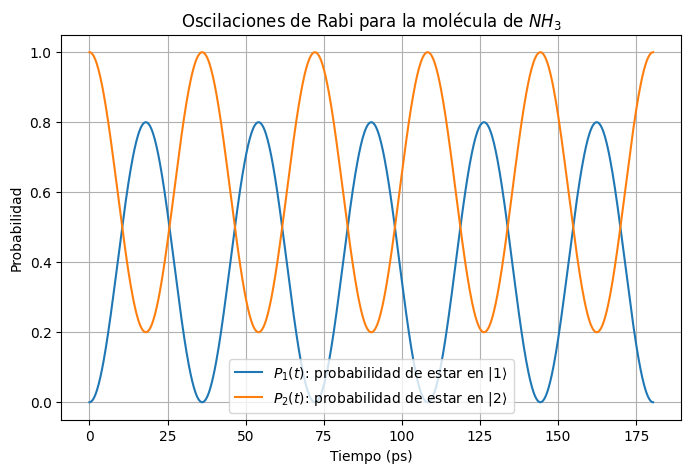

f_R = 24.7900 GHz
f_eff = 27.7161 GHz
T_eff = 36.0802 ps
Amplitud máxima de transición = 0.8000


In [ ]:
# Frecuencia de Rabi dada para NH3
f_R = 24.79e9  # Hz

# Frecuencia angular de Rabi
Omega_R = 2 * np.pi * f_R  # rad/s

# Detuning
Delta = Omega_R / 2  # rad/s

# Frecuencia angular efectiva
Omega_eff = np.sqrt(Omega_R**2 + Delta**2)

# Frecuencia efectiva en Hz
f_eff = Omega_eff / (2 * np.pi)

# Amplitud máxima de transición
A = Omega_R**2 / Omega_eff**2

# Periodo efectivo de la oscilación
T_eff = 1 / f_eff

# Tiempo: graficamos varios periodos
t = np.linspace(0, 5*T_eff, 1000)

# Probabilidad de pasar de |2> a |1>
P1 = A * np.sin(Omega_eff * t / 2)**2

# Probabilidad de permanecer en |2>
P2 = 1 - P1

# Gráfica
plt.figure(figsize=(8, 5))

plt.plot(t * 1e12, P1, label=r"$P_1(t)$: probabilidad de estar en $|1\rangle$")
plt.plot(t * 1e12, P2, label=r"$P_2(t)$: probabilidad de estar en $|2\rangle$")

plt.xlabel("Tiempo (ps)")
plt.ylabel("Probabilidad")
plt.title("Oscilaciones de Rabi para la molécula de $NH_3$")
plt.grid(True)
plt.legend()
plt.show()

print(f"f_R = {f_R/1e9:.4f} GHz")
print(f"f_eff = {f_eff/1e9:.4f} GHz")
print(f"T_eff = {T_eff*1e12:.4f} ps")
print(f"Amplitud máxima de transición = {A:.4f}")

Para la molécula de $NH_3$, la frecuencia de Rabi resonante dada es $f_R=24.79\ \text{GHz}$. Al considerar un detuning $\Delta=\Omega_R/2$, la frecuencia efectiva de Rabi aumenta a $f_{\text{eff}}\approx 27.72\ \text{GHz}$. Además, el detuning reduce la amplitud máxima de transición entre los estados, por la tanto la probabilidad máxima de pasar del estado inicial $|2\rangle$ al estado $|1\rangle$ es de $0.8$, es decir, un 80%. Por tanto, el sistema presenta oscilaciones de Rabi incompletas debido a la diferencia de frecuencia introducida por el detuning.

#Bell state.

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a Bell state (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

In [ ]:
# Simulador
simulator = AerSimulator()

qc = QuantumCircuit(2, 2)# Crear circuito de 2 qubits y 2 bits clásicos
qc.h(0)#Hadamard en el qubit 0

CNOT con control 0 y objetivo 1
qc.cx(0, 1)

qc.measure(0,0)
qc.measure(1,1)
print(qc.draw())

# Ejecutar simulación
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts()

print(counts)

# Histograma
plot_histogram(counts)
plt.show()

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
{'00': 537, '11': 487}


2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

In [ ]:
simulator = AerSimulator()
qc = QuantumCircuit(3, 3)

# Crear entrelazamiento
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

# Dibujar circuito
print(qc.draw())

# Simular
compiled_circuit =transpile(qc, simulator)
result =simulator.run(compiled_circuit, shots=1024).result()
counts= result.get_counts()

print(counts)

# Histograma
plot_histogram(counts)
plt.show()

     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 
{'111': 511, '000': 513}


3. See your results shift by adding qc.x(1) to the end of the circuit.

In [ ]:
simulator = AerSimulator()
qc = QuantumCircuit(3, 3)

# Crear estado GHZ
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

qc.x(1)# Aplicar X al qubit 1 antes de medir

qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

# Dibujar circuito
print(qc.draw())

# Simular
compiled_circuit = transpile(qc, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts()

print(counts)

# Histograma
plot_histogram(counts)
plt.show()

     ┌───┐          ┌─┐        
q_0: ┤ H ├──■───────┤M├────────
     └───┘┌─┴─┐     └╥┘┌───┐┌─┐
q_1: ─────┤ X ├──■───╫─┤ X ├┤M├
          └───┘┌─┴─┐ ║ └┬─┬┘└╥┘
q_2: ──────────┤ X ├─╫──┤M├──╫─
               └───┘ ║  └╥┘  ║ 
c: 3/════════════════╩═══╩═══╩═
                     0   2   1 
{'010': 538, '101': 486}
